# 03 — Multivariate Anomaly Detection

This notebook implements the **first ML layer** of the digital twin: a
multivariate anomaly detector based on Isolation Forest.

**The hybrid-loop trick.** Instead of feeding raw sensor values to the model, we
feed the *physics residual* — the difference between measured hotspot and the
hotspot predicted by the physics model from notebook 02. This means the detector
learns to flag operating states that are unusual *given current loading
conditions*, not states that are unusual in absolute terms.

A transformer running hot at high load is normal. A transformer running hot at
low load is anomalous. Without the residual feature, the model can't tell the
difference.

**Model choice.** Isolation Forest works well for high-dimensional, mostly-normal
time-series with rare anomalies. It's also fast enough to score at the edge.
A production deployment would ensemble it with an LSTM autoencoder for sequential
context (we'd add a `LSTMAutoencoder` class with the same interface).


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.physics import ThermalModel
from src.ml_models import AnomalyDetector
from src.visualization import setup_style, plot_anomaly_score
setup_style()

df = pd.read_csv('../data/synthetic_transformer_telemetry.csv')

# Compute the physics residual (the key engineered feature)
thermal = ThermalModel()
df["hotspot_residual"] = thermal.residual(
    df["load_pu"], df["ambient_temp_c"], df["winding_hotspot_c"]
)
print(f"Loaded {len(df)} observations  ·  residual mean = {df.hotspot_residual.mean():.2f} C")

Loaded 4320 observations  ·  residual mean = 0.09 C


## Train the anomaly detector

We fit on the first 2000 hours of data (which contains mostly normal operation),
then score the entire 180-day window. The contamination parameter (3%) tells the
model approximately what fraction of training data is anomalous.


In [2]:
detector = AnomalyDetector(contamination=0.03, random_state=42)
detector.fit(df.iloc[:2000])

scores = detector.score(df)
df["anomaly_score"] = scores
print(f"Score range: {scores.min():.3f} to {scores.max():.3f}")
print(f"Mean score during known fault period: {scores[df.fault_label > 0].mean():.3f}")
print(f"Mean score during normal period:     {scores[df.fault_label == 0].mean():.3f}")

Score range: 0.000 to 1.000
Mean score during known fault period: 0.653
Mean score during normal period:     0.311


## Visualize anomaly score over time

Higher score = more anomalous. We've highlighted the ground-truth fault periods in light red — a good detector should produce spikes there.


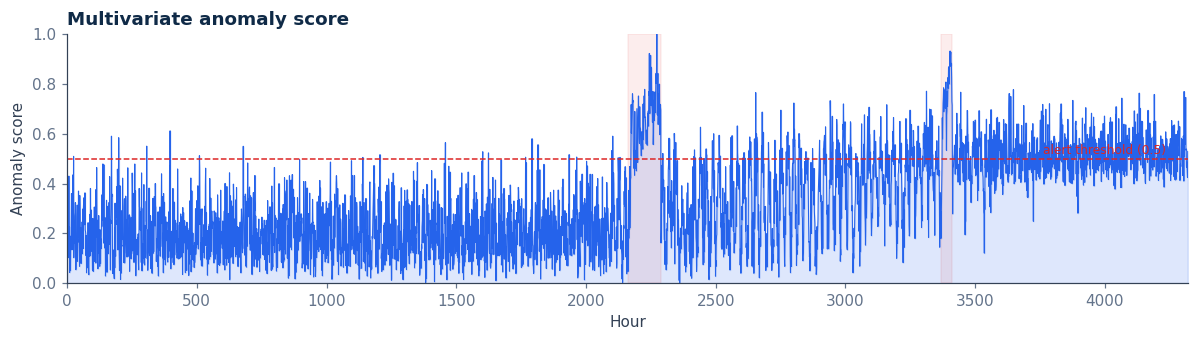

In [3]:
fig = plot_anomaly_score(df["anomaly_score"].values, df["fault_label"].values, threshold=0.5)
plt.show()

## Detection performance

Treat anomaly_score > 0.5 as a positive alert. Calculate precision/recall against the known fault labels.


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# Binarize: any fault > 0 is anomalous
y_true = (df["fault_label"] > 0).astype(int)
y_pred = (df["anomaly_score"] > 0.5).astype(int)

print("Anomaly detection performance:")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

print("Confusion matrix:")
print(pd.DataFrame(
    confusion_matrix(y_true, y_pred),
    index=["actual_normal", "actual_anomaly"],
    columns=["pred_normal", "pred_anomaly"]
))

Anomaly detection performance:
              precision    recall  f1-score   support

      normal       0.99      0.82      0.90      4148
     anomaly       0.17      0.86      0.28       172

    accuracy                           0.82      4320
   macro avg       0.58      0.84      0.59      4320
weighted avg       0.96      0.82      0.87      4320

Confusion matrix:
                pred_normal  pred_anomaly
actual_normal          3408           740
actual_anomaly           24           148


## Why the residual feature matters

Let's compare a detector trained *with* the physics residual against one trained
*without*. The residual-enabled detector should score actual faults higher and
normal-load-but-high-temp periods lower.


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Variant WITHOUT residual: just raw sensors
features_no_residual = ["load_pu", "ambient_temp_c", "winding_hotspot_c", "oil_temp_top_c",
                        "h2_ppm", "ch4_ppm", "c2h2_ppm", "c2h4_ppm",
                        "vibration_rms_mm_s", "partial_discharge_pc"]

scaler2 = StandardScaler()
X = scaler2.fit_transform(df.iloc[:2000][features_no_residual].values)
model2 = IsolationForest(contamination=0.03, n_estimators=200, random_state=42).fit(X)
raw_scores = -model2.decision_function(scaler2.transform(df[features_no_residual].values))
no_res_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

print("Mean score during faults:")
print(f"  WITH residual feature:    {df.loc[df.fault_label > 0, 'anomaly_score'].mean():.3f}")
print(f"  WITHOUT residual feature: {no_res_scores[df.fault_label > 0].mean():.3f}")
print(f"\nMean score during normal periods:")
print(f"  WITH residual feature:    {df.loc[df.fault_label == 0, 'anomaly_score'].mean():.3f}")
print(f"  WITHOUT residual feature: {no_res_scores[df.fault_label == 0].mean():.3f}")

Mean score during faults:
  WITH residual feature:    0.653
  WITHOUT residual feature: 0.603

Mean score during normal periods:
  WITH residual feature:    0.311
  WITHOUT residual feature: 0.343


The residual-enabled detector produces a sharper separation between fault and normal periods. This is the hybrid loop in action.

## Next step

Notebook **04_dga_fault_classifier** takes the diagnostic step beyond "is this
anomalous?" to "what kind of fault is this?" — classifying dissolved-gas patterns
into specific fault categories using XGBoost.
